# Step 4 — Outlier Detection
**COSC 3337 | Group Project Check-in #3**

We use **Isolation Forest** to identify songs and artists that are statistical anomalies in each user's listening history, then check whether any outliers are shared between users.

### Why Isolation Forest?
Spotify listening data is highly right-skewed — most songs are played 1–3 times, but a handful are played hundreds of times. Isolation Forest handles this well because it doesn't assume a Gaussian distribution; it isolates anomalies by randomly partitioning the feature space. Anomalies get isolated in fewer cuts and receive a higher anomaly score.

### Features used for song-level outlier detection
| Feature | What it captures |
|---|---|
| `play_count` | How many times the song was played |
| `total_min` | Total listening time in minutes |
| `avg_min` | Average duration per play |
| `skip_rate` | Fraction of plays under 30 seconds |
| `hour_spread` | Std dev of the hour-of-day it was played (listening variety) |
| `unique_days` | Number of distinct days it was played |


In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':'#0D0D0D','axes.facecolor':'#1A1A1A',
    'axes.edgecolor':'#444','text.color':'white',
    'xtick.color':'white','ytick.color':'white',
    'axes.labelcolor':'white','axes.titlecolor':'white',
    'legend.facecolor':'#333','legend.edgecolor':'#555',
    'figure.dpi': 120,
})
COLORS = {'S':'#1DB954', 'J':'#FF6B6B'}


## 1. Load Data

In [2]:
BASE = os.path.abspath('.')

def load_user(folder):
    records = []
    for i in range(5):
        try: records += json.load(open(f'{BASE}/public/{folder}/StreamingHistory_music_{i}.json', encoding='utf-8'))
        except FileNotFoundError: break
    df = pd.DataFrame(records)
    df = df[df['msPlayed'] >= 5000].copy()
    df['endTime'] = pd.to_datetime(df['endTime'])
    df['minutes'] = df['msPlayed'] / 60000
    df['hour']    = df['endTime'].dt.hour
    df['date']    = df['endTime'].dt.date
    return df

sri = load_user('s')
jan = load_user('j')
print(f'Sriharsha: {len(sri):,} plays  |  Janya: {len(jan):,} plays')


Sriharsha: 10,422 plays  |  Janya: 14,153 plays


## 2. Feature Engineering

In [3]:
def song_outlier_features(df):
    g = df.groupby(['artistName', 'trackName'])
    feat = pd.DataFrame({
        'play_count':  g['msPlayed'].count(),
        'total_min':   g['minutes'].sum(),
        'avg_min':     g['minutes'].mean(),
        'skip_rate':   g['msPlayed'].apply(lambda x: (x < 30_000).sum()) / g['msPlayed'].count(),
        'hour_spread': g['hour'].apply(lambda x: x.std() if len(x) > 1 else 0),
        'unique_days': g['date'].nunique(),
    }).reset_index()
    return feat

def artist_outlier_features(df):
    g = df.groupby('artistName')
    feat = pd.DataFrame({
        'play_count':      g['msPlayed'].count(),
        'total_min':       g['minutes'].sum(),
        'track_diversity': g['trackName'].nunique(),
        'skip_rate':       g['msPlayed'].apply(lambda x: (x < 30_000).sum()) / g['msPlayed'].count(),
        'unique_days':     g['date'].nunique(),
    }).reset_index()
    return feat

SONG_FEATURES   = ['play_count','total_min','avg_min','skip_rate','hour_spread','unique_days']
ARTIST_FEATURES = ['play_count','total_min','track_diversity','skip_rate','unique_days']

song_feat_s   = song_outlier_features(sri)
song_feat_j   = song_outlier_features(jan)
artist_feat_s = artist_outlier_features(sri)
artist_feat_j = artist_outlier_features(jan)

print(f'Unique songs  — S: {len(song_feat_s):,}   J: {len(song_feat_j):,}')
print(f'Unique artists — S: {len(artist_feat_s):,}   J: {len(artist_feat_j):,}')


Unique songs  — S: 2,896   J: 3,247
Unique artists — S: 775   J: 1,104


## 3. Isolation Forest — Song Level

We train a separate model for each user (contamination = 5%).  
A higher anomaly score means the song is more unusual relative to that user's overall catalogue.


In [4]:
def run_iforest(feat_df, features, contamination=0.05):
    X = feat_df[features].fillna(0).values
    Xs = StandardScaler().fit_transform(X)
    clf = IsolationForest(contamination=contamination, random_state=42, n_estimators=200)
    feat_df = feat_df.copy()
    feat_df['anomaly_score'] = -clf.fit(Xs).score_samples(Xs)
    feat_df['is_outlier']    = clf.predict(Xs) == -1
    return feat_df

song_feat_s = run_iforest(song_feat_s, SONG_FEATURES)
song_feat_j = run_iforest(song_feat_j, SONG_FEATURES)

print(f'Outlier songs — S: {song_feat_s.is_outlier.sum()}   J: {song_feat_j.is_outlier.sum()}')


Outlier songs — S: 145   J: 163


### Top Outlier Songs — Sriharsha

In [5]:
def show_top_song_outliers(feat, n=12):
    top = feat[feat['is_outlier']].sort_values('anomaly_score', ascending=False).head(n)
    for _, r in top.iterrows():
        print(f"  score={r['anomaly_score']:.3f}  plays={int(r['play_count']):>4}  "
              f"total={r['total_min']:>7.1f} min  skip={r['skip_rate']:.2f}  "
              f"{r['artistName']} – {r['trackName']}")

show_top_song_outliers(song_feat_s)


  score=0.748  plays=  34  total=  192.1 min  skip=0.00  Yoko Shimomura – Vector to the Heavens - Xion-
  score=0.744  plays=  41  total=  138.6 min  skip=0.02  須田景凪 – veil
  score=0.743  plays=  34  total=  148.3 min  skip=0.00  Ado – Elf
  score=0.735  plays=  38  total=   86.9 min  skip=0.18  Dude's Cover – Never Meant to Belong (Acoustic Version) (From "Bleach: Thousand Year Blood War")
  score=0.734  plays=  34  total=  152.2 min  skip=0.00  Yoko Shimomura – The Other Promise
  score=0.726  plays=  41  total=  115.4 min  skip=0.02  Good Kid – Osmosis
  score=0.725  plays=  32  total=  112.5 min  skip=0.03  Yoko Shimomura – Valse di Fantastica
  score=0.721  plays=  39  total=  103.6 min  skip=0.05  Good Kid – Mimi's Delivery Service
  score=0.721  plays=  35  total=  120.5 min  skip=0.00  BoyWithUke – Migraine
  score=0.721  plays=  32  total=  115.0 min  skip=0.06  Yoko Shimomura – Musique pour la tristesse de Xion
  score=0.711  plays=  33  total=  116.9 min  skip=0.00  石元 丈晴 – 

### Top Outlier Songs — Janya

In [6]:
show_top_song_outliers(song_feat_j)


  score=0.756  plays= 108  total=  169.1 min  skip=0.08  jtski – #brrrrrrr
  score=0.754  plays= 101  total=  180.6 min  skip=0.07  Nettspend – Tommy
  score=0.753  plays=  88  total=  163.7 min  skip=0.03  Nine Vicious – My Speakers
  score=0.751  plays=  85  total=  231.1 min  skip=0.07  Real Boston Richey – On Site
  score=0.750  plays=  66  total=  269.2 min  skip=0.03  Yeat – Lying 4 fun
  score=0.746  plays=  90  total=  235.5 min  skip=0.09  Summrs – Nightfall Outro
  score=0.743  plays=  94  total=  123.7 min  skip=0.05  Duwap Kaine – I Lost
  score=0.742  plays=  89  total=  105.5 min  skip=0.20  Lil Tracy – I Don't Want To Ever Fall In Love Now
  score=0.742  plays=  87  total=  197.5 min  skip=0.06  Nine Vicious – Tokyo
  score=0.740  plays=  78  total=  234.1 min  skip=0.05  Yeat – FATË (BONUS)
  score=0.734  plays=  90  total=  151.7 min  skip=0.09  Nine Vicious – Hit Em Up
  score=0.734  plays=  78  total=  179.0 min  skip=0.06  Nine Vicious – Conversating


## 4. Isolation Forest — Artist Level

In [7]:
artist_feat_s = run_iforest(artist_feat_s, ARTIST_FEATURES)
artist_feat_j = run_iforest(artist_feat_j, ARTIST_FEATURES)

def show_top_artist_outliers(feat, n=10):
    top = feat[feat['is_outlier']].sort_values('anomaly_score', ascending=False).head(n)
    for _, r in top.iterrows():
        print(f"  score={r['anomaly_score']:.3f}  plays={int(r['play_count']):>4}  "
              f"total={r['total_min']:>8.1f} min  tracks={int(r['track_diversity']):>3}  "
              f"{r['artistName']}")

print("Sriharsha — Top Outlier Artists:")
show_top_artist_outliers(artist_feat_s)
print()
print("Janya — Top Outlier Artists:")
show_top_artist_outliers(artist_feat_j)


Sriharsha — Top Outlier Artists:
  score=0.812  plays= 496  total=  1627.5 min  tracks=141  Lorien Testard
  score=0.797  plays= 498  total=  1462.2 min  tracks= 59  Yoko Shimomura
  score=0.785  plays= 306  total=   842.5 min  tracks= 32  MICO
  score=0.776  plays= 331  total=   883.7 min  tracks= 27  Good Kid
  score=0.775  plays= 298  total=   851.0 min  tracks= 26  The Vanished People
  score=0.757  plays= 280  total=   792.6 min  tracks= 43  BoyWithUke
  score=0.751  plays= 262  total=   677.3 min  tracks= 38  again&again
  score=0.740  plays= 206  total=   746.5 min  tracks= 42  Ado
  score=0.725  plays= 195  total=   598.8 min  tracks= 15  Kevin Walkman
  score=0.709  plays= 133  total=   496.7 min  tracks= 33  ZUTOMAYO

Janya — Top Outlier Artists:
  score=0.849  plays= 849  total=  2068.3 min  tracks= 72  Yeat
  score=0.825  plays= 443  total=   989.7 min  tracks= 82  YoungBoy Never Broke Again
  score=0.816  plays= 670  total=  1356.7 min  tracks= 25  Nine Vicious
  score=0.7

## 5. Shared Outliers Between Users

In [8]:
out_artists_s = set(artist_feat_s[artist_feat_s.is_outlier]['artistName'])
out_artists_j = set(artist_feat_j[artist_feat_j.is_outlier]['artistName'])
shared_artists = out_artists_s & out_artists_j

out_songs_s = set(zip(song_feat_s[song_feat_s.is_outlier]['artistName'],
                      song_feat_s[song_feat_s.is_outlier]['trackName']))
out_songs_j = set(zip(song_feat_j[song_feat_j.is_outlier]['artistName'],
                      song_feat_j[song_feat_j.is_outlier]['trackName']))
shared_songs = out_songs_s & out_songs_j

print("Shared outlier artists:", shared_artists or "None")
print("Shared outlier songs:  ", shared_songs   or "None")


Shared outlier artists: None
Shared outlier songs:   None


## 6. Temporal Binge Outliers (Z-Score on Daily Totals)

Beyond song/artist level, we look for days where each user's total listening time was more than 3 standard deviations above their personal average — these are genuine binge sessions.


Sriharsha  μ=108.2 min/day  σ=82.8
  2025-12-06: 570 min  (z=5.58)
  2025-03-02: 389 min  (z=3.39)
  2026-02-09: 358 min  (z=3.02)

Janya  μ=82.2 min/day  σ=66.3
  2025-05-17: 364 min  (z=4.25)
  2025-05-14: 294 min  (z=3.19)
  2025-07-05: 281 min  (z=3.00)



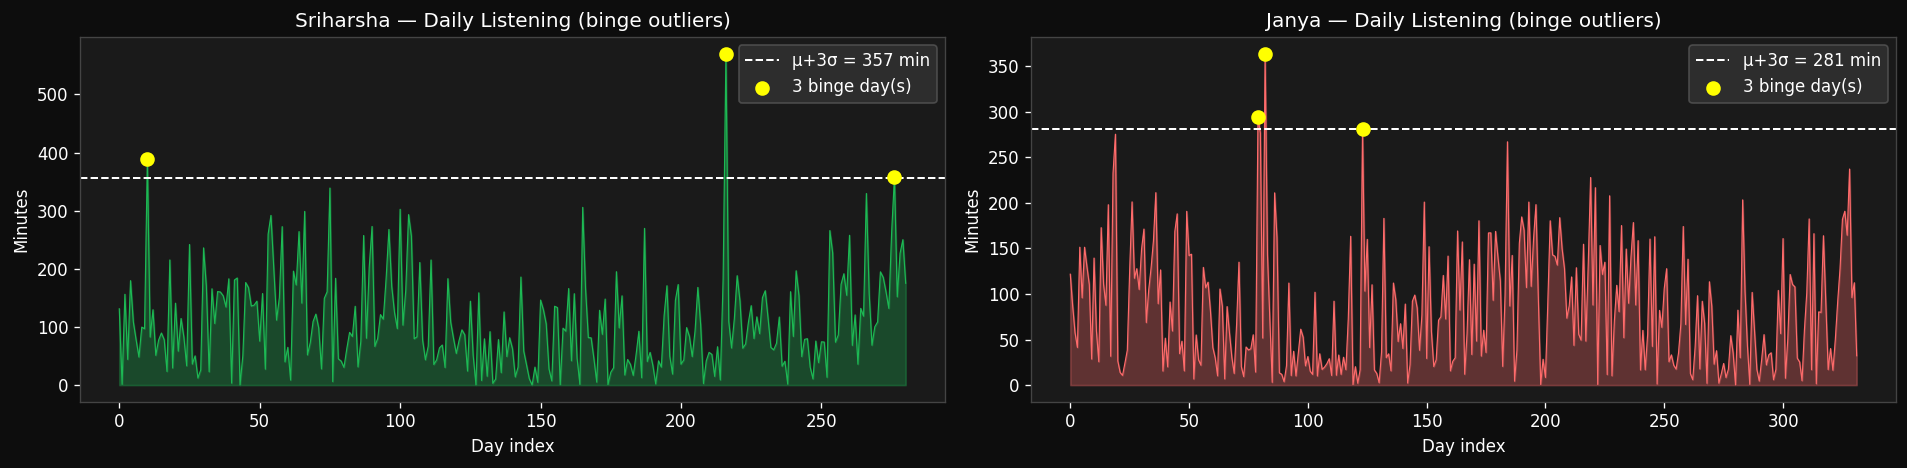

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for ax, (name, df, col) in zip(axes, [('Sriharsha', sri, COLORS['S']), ('Janya', jan, COLORS['J'])]):
    daily = df.groupby('date')['minutes'].sum().sort_index()
    mu, sigma = daily.mean(), daily.std()
    threshold = mu + 3 * sigma
    
    idx = list(range(len(daily)))
    ax.fill_between(idx, daily.values, alpha=0.3, color=col)
    ax.plot(idx, daily.values, lw=0.7, color=col)
    ax.axhline(threshold, ls='--', color='white', lw=1.2,
               label=f'μ+3σ = {threshold:.0f} min')
    
    binge_idx = [i for i,v in enumerate(daily.values) if v > threshold]
    ax.scatter(binge_idx, [daily.values[i] for i in binge_idx],
               color='yellow', s=60, zorder=5,
               label=f'{len(binge_idx)} binge day(s)')
    
    ax.set_title(f'{name} — Daily Listening (binge outliers)')
    ax.set_xlabel('Day index'); ax.set_ylabel('Minutes')
    ax.legend()
    
    print(f"{name}  μ={mu:.1f} min/day  σ={sigma:.1f}")
    binge = daily[daily > threshold].sort_values(ascending=False)
    for d, v in binge.items():
        print(f"  {d}: {v:.0f} min  (z={(v-mu)/sigma:.2f})")
    print()

plt.tight_layout()
plt.savefig('outlier_binge.png', bbox_inches='tight', facecolor='#0D0D0D')
plt.show()


## 7. Visualisations

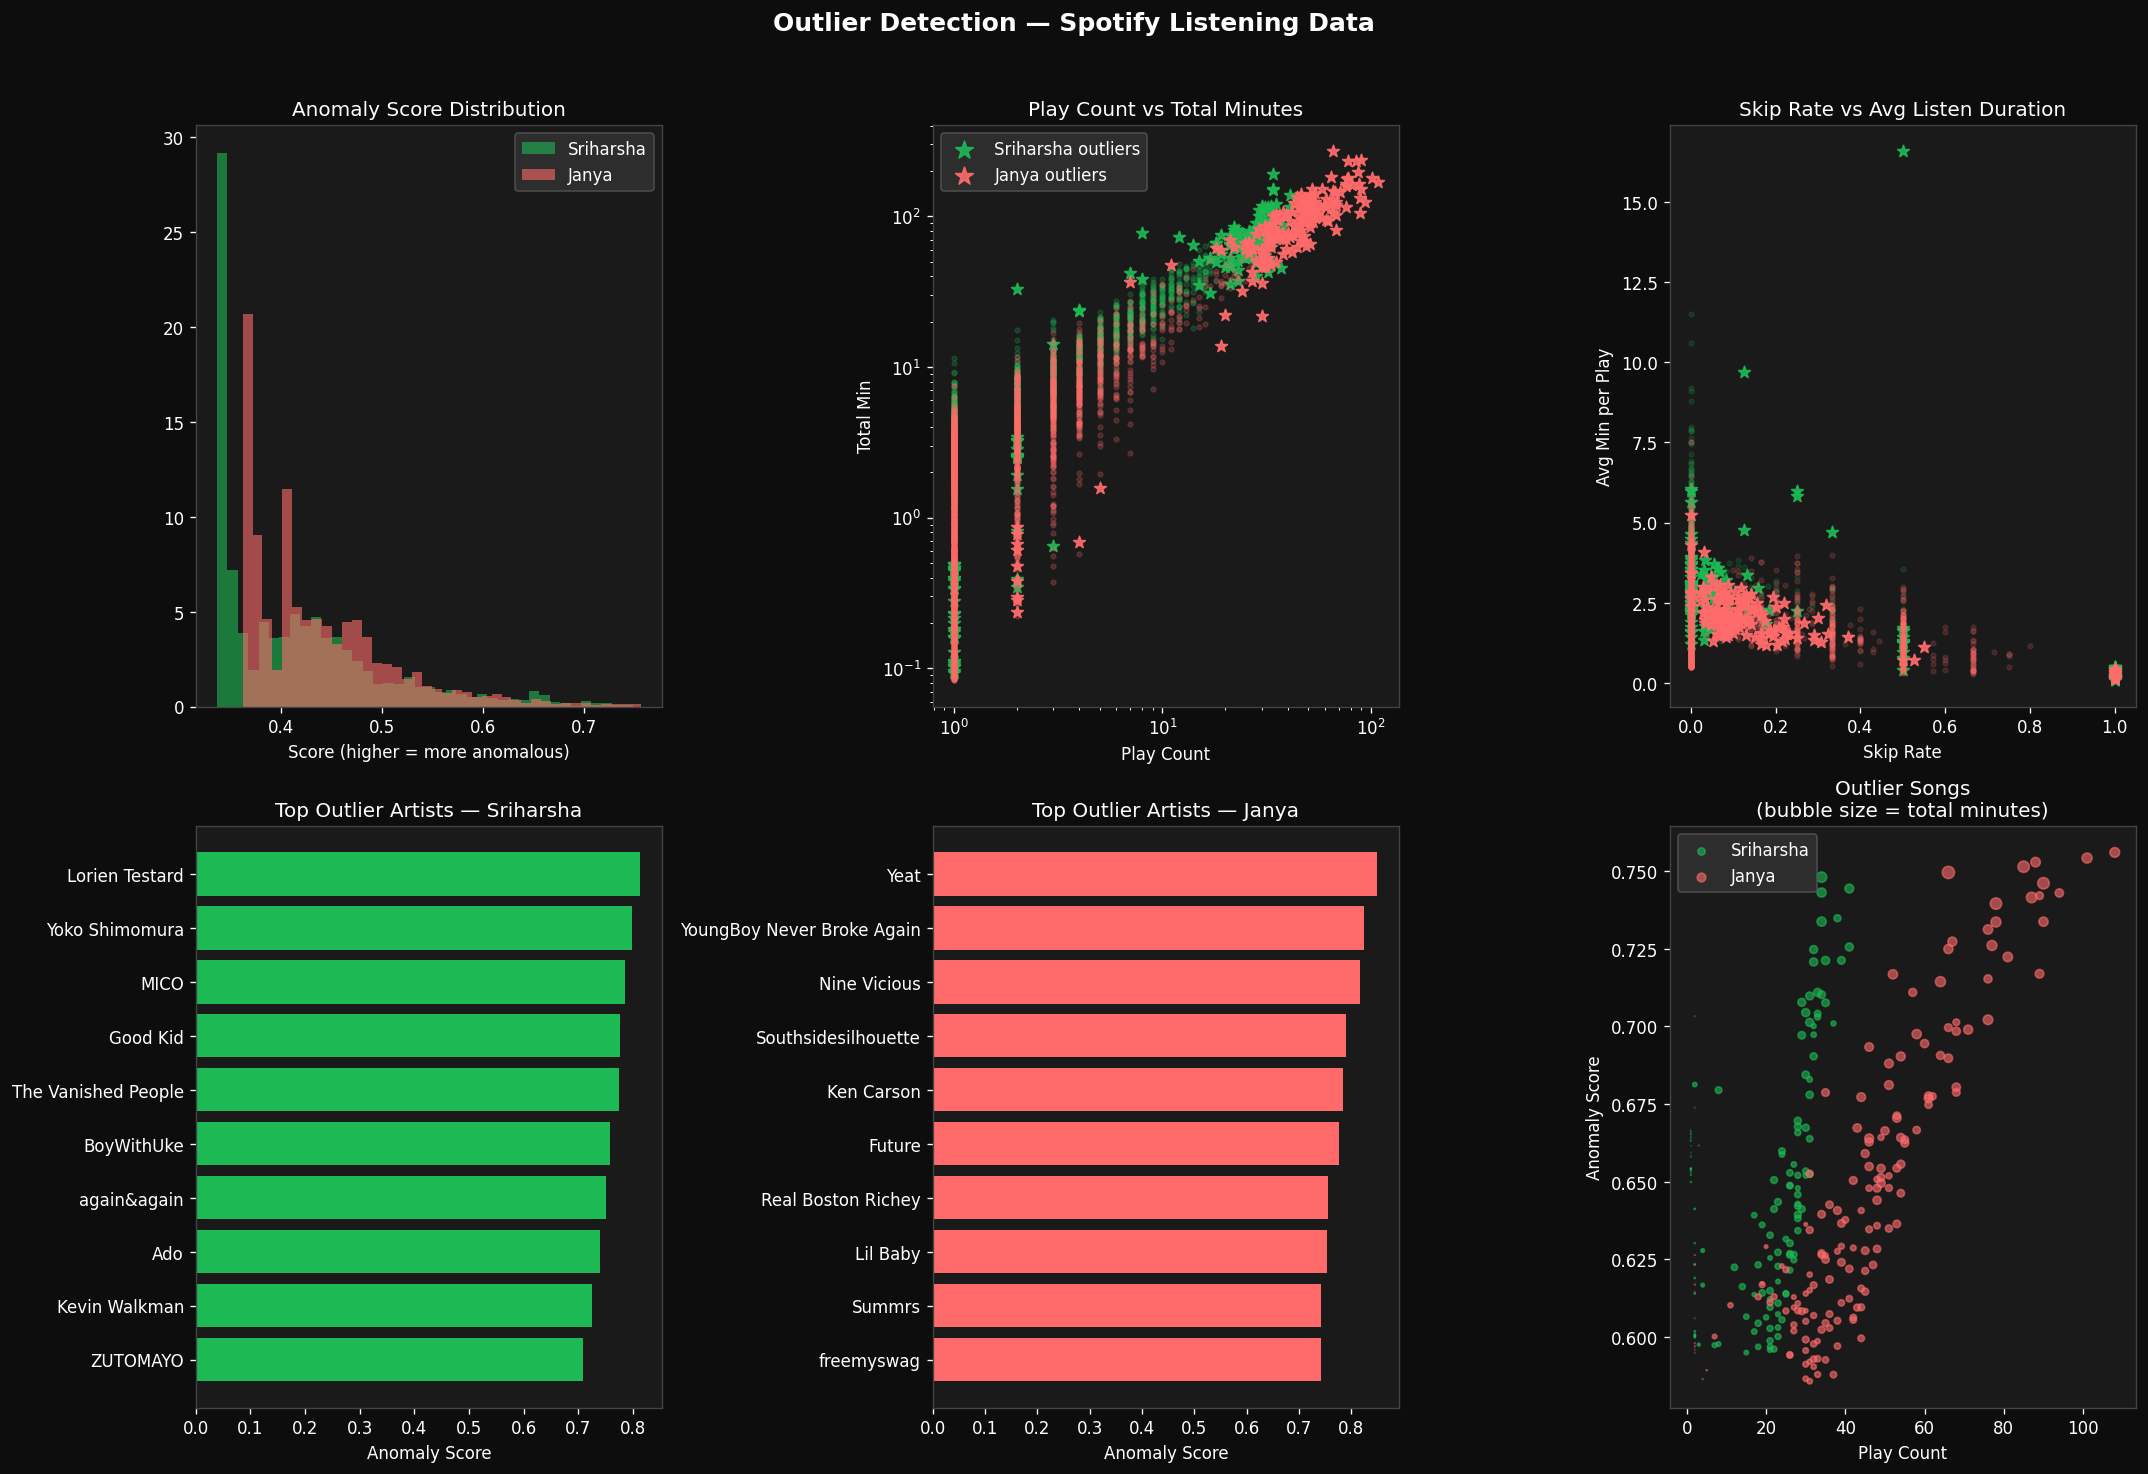

Saved outlier_summary.png


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Anomaly score distributions
ax = axes[0,0]
for name, feat, col in [('Sriharsha', song_feat_s, COLORS['S']),
                         ('Janya',     song_feat_j, COLORS['J'])]:
    ax.hist(feat['anomaly_score'], bins=40, alpha=0.6, color=col,
            label=name, density=True)
ax.set_title('Anomaly Score Distribution')
ax.set_xlabel('Score (higher = more anomalous)')
ax.legend()

# 2. Play count vs total min — outliers starred
ax = axes[0,1]
for name, feat, col in [('Sriharsha', song_feat_s, COLORS['S']),
                         ('Janya',     song_feat_j, COLORS['J'])]:
    norm = feat[~feat['is_outlier']]
    out  = feat[feat['is_outlier']]
    ax.scatter(norm['play_count'], norm['total_min'],
               alpha=0.2, s=8, color=col)
    ax.scatter(out['play_count'],  out['total_min'],
               alpha=0.9, s=55, color=col, marker='*',
               label=f'{name} outliers')
ax.set_title('Play Count vs Total Minutes')
ax.set_xlabel('Play Count'); ax.set_ylabel('Total Min')
ax.set_xscale('log'); ax.set_yscale('log')
ax.legend(markerscale=1.5)

# 3. Skip rate vs avg duration
ax = axes[0,2]
for name, feat, col in [('Sriharsha', song_feat_s, COLORS['S']),
                         ('Janya',     song_feat_j, COLORS['J'])]:
    norm = feat[~feat['is_outlier']]
    out  = feat[feat['is_outlier']]
    ax.scatter(norm['skip_rate'], norm['avg_min'], alpha=0.15, s=8, color=col)
    ax.scatter(out['skip_rate'],  out['avg_min'],  alpha=0.9,  s=55, color=col, marker='*')
ax.set_title('Skip Rate vs Avg Listen Duration')
ax.set_xlabel('Skip Rate'); ax.set_ylabel('Avg Min per Play')

# 4. Top outlier artists — Sri
ax = axes[1,0]
top = artist_feat_s[artist_feat_s.is_outlier].sort_values('anomaly_score', ascending=False).head(10)
ax.barh(top['artistName'][::-1], top['anomaly_score'][::-1], color=COLORS['S'])
ax.set_title('Top Outlier Artists — Sriharsha')
ax.set_xlabel('Anomaly Score')

# 5. Top outlier artists — Janya
ax = axes[1,1]
top = artist_feat_j[artist_feat_j.is_outlier].sort_values('anomaly_score', ascending=False).head(10)
ax.barh(top['artistName'][::-1], top['anomaly_score'][::-1], color=COLORS['J'])
ax.set_title('Top Outlier Artists — Janya')
ax.set_xlabel('Anomaly Score')

# 6. Bubble chart — outlier songs by play count & score
ax = axes[1,2]
for name, feat, col in [('Sriharsha', song_feat_s, COLORS['S']),
                         ('Janya',     song_feat_j, COLORS['J'])]:
    out = feat[feat['is_outlier']]
    ax.scatter(out['play_count'], out['anomaly_score'],
               s=out['total_min'] / 5, alpha=0.6, color=col, label=name)
ax.set_title('Outlier Songs\n(bubble size = total minutes)')
ax.set_xlabel('Play Count'); ax.set_ylabel('Anomaly Score')
ax.legend()

plt.suptitle('Outlier Detection — Spotify Listening Data', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outlier_summary.png', bbox_inches='tight', facecolor='#0D0D0D')
plt.show()
print("Saved outlier_summary.png")


## 8. Summary & Interpretation

### Sriharsha's Outliers
**Top outlier artists:** Lorien Testard (496 plays, 1,628 min, **141 unique tracks**), Yoko Shimomura (Kingdom Hearts composer, 498 plays, 1,462 min)

The anomaly here is driven by *breadth and volume together*. Lorien Testard's 141 tracks is the single most extreme value for `track_diversity` in the dataset — Sri has explored this artist far more thoroughly than anyone else. Yoko Shimomura's game soundtracks stand out because of extremely low skip rates (0.00) paired with high total time, indicating Sri completes nearly every listen.

**Top outlier songs:** Kingdom Hearts tracks ("Vector to the Heavens", "The Other Promise") and Japanese indie/vocaloid songs — all with skip rates near 0, meaning Sri listens through these every single time.

**Binge days:** 3 days exceeded μ+3σ, peaking at **570 min (9.5 hrs)** on Dec 6, 2025.

---

### Janya's Outliers
**Top outlier artists:** Yeat (849 plays, 2,068 min), Nine Vicious (670 plays), YoungBoy Never Broke Again (443 plays)

Janya's outliers are driven by *extreme play count concentration*. Yeat alone accounts for more than 2,000 minutes — nearly 34 hours of listening. The pattern is short high-energy SoundCloud-rap tracks looped intensively over a narrow period. Nine Vicious is notable for having only 25 unique tracks but 670 plays — a very deep single-artist loop.

**Top outlier songs:** "#brrrrrrr" – jtski (108 plays), "Tommy" – Nettspend (101 plays), "Lying 4 fun" – Yeat (66 plays, 269 min). These are short tracks (avg ~1.5–2 min) played on tight repeat loops.

**Binge days:** 3 days exceeded μ+3σ, peaking at **364 min** on May 17, 2025.

---

### Shared Outliers
**None.** No songs or artists are outliers for *both* users simultaneously. This is consistent with the clustering result (ARI ≈ 0.05) — the two users occupy almost entirely separate musical spaces. Where Sri's extremes are Japanese OST and ambient music, Janya's extremes are SoundCloud rap. The only observable commonality is the *pattern of obsession* itself: both users have a small set of artists they loop intensively, it's just different artists entirely.

---

### Methodological Notes
- Contamination was set to **5%** (Isolation Forest expects ~5% of the data to be outliers). Lowering to 2% surfaces only the most extreme cases; raising it to 10% reveals subtler patterns.
- Binge detection used **z-score (μ + 3σ)** on daily totals — a simple and interpretable threshold.
- Artist and song outlier detection were run **separately per user** rather than jointly, so scores are relative to each person's own catalogue, not to a combined pool.
